# Facial Keypoints Detection - Introduction

This project aims to detect key facial landmarks (such as the eyes, nose, and mouth corners) using deep learning techniques. Using the dataset provided by Kaggle, we work with 96x96 grayscale images of human faces and attempt to predict 15 key points on each face.

Facial keypoints detection is a fundamental task in various computer vision applications, including face recognition, facial expression analysis, and augmented reality.

In this notebook, we:
- Preprocess and normalize the image data,
- Clean missing or incomplete keypoint annotations,
- Apply data augmentation to improve generalization,
- Build and train a Convolutional Neural Network (CNN),
- Visualize training performance and evaluate the model.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
# Load and clean the data
df = pd.read_csv("training.csv")
df = df.dropna()  # Drop rows with missing values

## EDA - Exploratory Data Analysis

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2140 entries, 0 to 2283
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   left_eye_center_x          2140 non-null   float64
 1   left_eye_center_y          2140 non-null   float64
 2   right_eye_center_x         2140 non-null   float64
 3   right_eye_center_y         2140 non-null   float64
 4   left_eye_inner_corner_x    2140 non-null   float64
 5   left_eye_inner_corner_y    2140 non-null   float64
 6   left_eye_outer_corner_x    2140 non-null   float64
 7   left_eye_outer_corner_y    2140 non-null   float64
 8   right_eye_inner_corner_x   2140 non-null   float64
 9   right_eye_inner_corner_y   2140 non-null   float64
 10  right_eye_outer_corner_x   2140 non-null   float64
 11  right_eye_outer_corner_y   2140 non-null   float64
 12  left_eyebrow_inner_end_x   2140 non-null   float64
 13  left_eyebrow_inner_end_y   2140 non-null   float64
 1

In [6]:
df.sample(3)

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,Image
2061,65.284400,33.760292,27.668818,41.002759,58.094721,37.377175,74.134306,32.678418,35.734438,40.739977,...,56.494428,68.660449,73.131182,39.684962,79.175829,54.463847,74.739391,54.547030,76.624877,45 52 59 62 74 71 75 83 94 100 85 81 80 71 73 ...
898,64.240390,36.564995,30.057366,36.913795,58.311024,36.913795,70.518634,36.913795,36.335610,37.611395,...,56.796098,57.264390,78.072976,37.731122,78.072976,47.846244,71.794732,47.846244,85.397854,220 216 216 209 197 181 182 184 201 220 225 20...
1506,64.022932,41.182124,27.657694,43.628404,57.663166,42.649954,72.176678,41.671505,35.159140,44.280704,...,63.686150,66.795049,79.830410,30.593042,81.461160,47.715752,78.689042,47.715752,85.537876,255 255 255 254 254 237 92 32 33 33 30 30 31 2...


In [7]:
df.shape

(2140, 31)

In [8]:
# Process images
X = df['Image'].apply(lambda x: np.fromstring(x, sep=' ').reshape(96, 96) / 255.0)
X = np.stack(X.to_numpy()).reshape(-1, 96, 96, 1)
y = df.drop(columns='Image').values

In [9]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Data augmentation
datagen = ImageDataGenerator(rotation_range=10,zoom_range=0.1,width_shift_range=0.1,height_shift_range=0.1)
datagen.fit(X_train)

In [11]:
# Model architecture
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(96,96,1)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(500, activation='relu'),
    Dropout(0.3),
    Dense(30)
])

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mean_squared_error')
model.summary()

D:\Anaconda\Anacondaa\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 94, 94, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 94, 94, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 47, 47, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 45, 45, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 20, 20, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 20, 20, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 10, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 500)                 │       6,400,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 500)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 30)                  │          15,030 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,509,098 (24.83 MB)

 Trainable params: 6,508,650 (24.83 MB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
# Callbacks
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True)

In [13]:
# Train the model
history = model.fit(datagen.flow(X_train, y_train, batch_size=32),validation_data=(X_val, y_val),epochs=100,callbacks=[early_stop, checkpoint])

D:\Anaconda\Anacondaa\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - loss: 518.9611

54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 264ms/step - loss: 513.8066 - val_loss: 2823.4236
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - loss: 113.0004

54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 258ms/step - loss: 112.7439 - val_loss: 2342.9773
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - loss: 82.8407

54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 261ms/step - loss: 82.7229 - val_loss: 1485.3403
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - loss: 72.7034

...

54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 249ms/step - loss: 43.1062 - val_loss: 22.8547
Epoch 13/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 251ms/step - loss: 37.3549 - val_loss: 76.4272
Epoch 14/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - loss: 40.1888

54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 251ms/step - loss: 40.2287 - val_loss: 22.2529
Epoch 15/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 250ms/step - loss: 36.9430 - val_loss: 23.1158
Epoch 16/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - loss: 38.4395

54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 249ms/step - loss: 38.3860 - val_loss: 13.3910
Epoch 17/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 254ms/step - loss: 35.4230 - val_loss: 33.5465
Epoch 18/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - loss: 39.8637

54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 250ms/step - loss: 39.8157 - val_loss: 11.9456
Epoch 19/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 263ms/step - loss: 33.1352 - val_loss: 14.6405
Epoch 20/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 249ms/step - loss: 32.4257 - val_loss: 12.8188
Epoch 21/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 264ms/step - loss: 32.8288 - val_loss: 18.4266
Epoch 22/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 251ms/step - loss: 33.5505 - val_loss: 24.6425
Epoch 23/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - loss: 32.6222

54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 252ms/step - loss: 32.5840 - val_loss: 10.2837
Epoch 24/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 249ms/step - loss: 32.4315 - val_loss: 19.9598
Epoch 25/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 250ms/step - loss: 28.9818 - val_loss: 55.9422
Epoch 26/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 264ms/step - loss: 28.4924 - val_loss: 12.5600
Epoch 27/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 257ms/step - loss: 28.9114 - val_loss: 26.6285
Epoch 28/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 261ms/step - loss: 29.2964 - val_loss: 16.6378


In [14]:
model.save("model.h5")

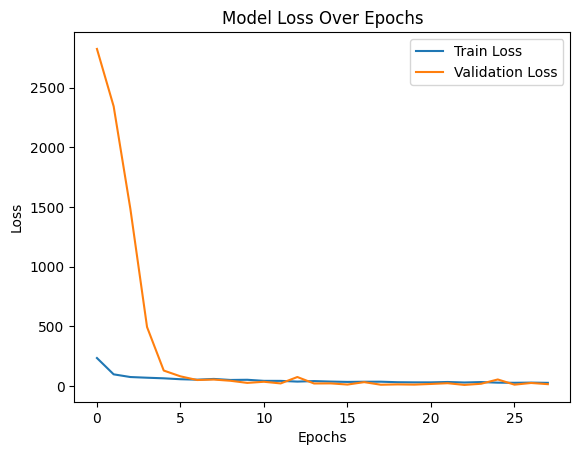

In [15]:
# Plot training history
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# Conclusion

In this study, we successfully developed a deep learning model that predicts facial keypoints with reasonable accuracy. By applying data augmentation, batch normalization, and dropout techniques, we improved the model's ability to generalize and avoid overfitting.

The results demonstrate that even with a relatively small dataset, a well-designed CNN architecture can learn to locate facial landmarks effectively. Further improvements could be made using more complex architectures, transfer learning, or custom loss functions.

This project provides a solid foundation for applications in biometric identification, emotion recognition, and face alignment systems.